# 5060 Final Project — Literature Search Pipeline

**Topic:** SNOMED-CT in Clinical NLP — A Scoping Review (2016–2026)

**Sections:**
0. Environment Setup
1. Clinical NLP Task Vocabulary
2. Database Registry
3. Stage 1 Metadata Schema
4. Query Construction
5. Paper Retrieval
6. Deduplication
7. Screening

---
## 0. Environment Setup

Run this cell **once** from any kernel to create the `meta_review` conda environment
and register it as a Jupyter kernel. Then restart Jupyter and select
**Python (meta_review)** as the kernel before running the rest of the notebook.

In [1]:
# %%bash
# conda create -n meta_review python=3.10 -y

# conda run -n meta_review pip install \
#     biopython \
#     arxiv \
#     requests \
#     acl-anthology \
#     bibtexparser \
#     pandas \
#     "thefuzz[speedup]" \
#     python-dotenv \
#     tqdm \
#     ipykernel

# conda run -n meta_review python -m ipykernel install \
#     --user \
#     --name meta_review \
#     --display-name "Python (meta_review)"

# echo "Done. Restart Jupyter and select the 'Python (meta_review)' kernel."

---
## Imports

In [2]:
import json
import os
import time
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

import requests
import pandas as pd
import bibtexparser
import arxiv
from Bio import Entrez, Medline
from dotenv import load_dotenv
from thefuzz import fuzz
from tqdm import tqdm

---
## 1. Clinical NLP Task Vocabulary

In [ ]:
VOCABULARY = {
    "meta": {
        "version": "1.0",
        "date": "2026-04-27",
        "anchor_papers": [
            {"id": "gao2022",      "citation": "Gao Y et al. JAMIA. 2022;29(10):1797-1806. doi:10.1093/jamia/ocac127"},
            {"id": "wu2022",       "citation": "Wu H et al. npj Digit Med. 2022;5:186. doi:10.1038/s41746-022-00730-6"},
            {"id": "lederman2022", "citation": "Lederman A et al. JAMIA. 2022;29(10):1810-1817. doi:10.1093/jamia/ocac121"},
            {"id": "jmir2024_dl",  "citation": "Task-Specific Transformer-Based Language Models in Health Care. JMIR Med Inform. 2024. doi:10.2196/49724. PMC11612605"}
        ]
    },
    "categories": [
        {"id": 1,  "name": "Named Entity Recognition",                          "search_terms": ["named entity recognition", "concept extraction", "entity extraction", "clinical NER", "disorder detection", "medical event identification"]},
        {"id": 2,  "name": "De-identification",                                 "search_terms": ["de-identification", "deidentification", "PHI detection", "anonymization", "patient identifier"]},
        {"id": 3,  "name": "Entity Linking / Concept Normalization",             "search_terms": ["entity linking", "concept normalization", "entity normalization", "concept mapping", "terminology mapping", "clinical concept normalization"]},
        {"id": 4,  "name": "Relation Extraction",                               "search_terms": ["relation extraction", "clinical relation extraction", "event extraction"]},
        {"id": 5,  "name": "Adverse Drug Event / Medication Extraction",        "search_terms": ["adverse drug event", "adverse drug reaction", "medication extraction", "drug extraction", "pharmacovigilance"]},
        {"id": 6,  "name": "Text / Document Classification",                   "search_terms": ["text classification", "document classification", "clinical phenotyping", "cohort selection", "smoking status", "risk assessment"]},
        {"id": 7,  "name": "Assertion / Negation Detection",                   "search_terms": ["assertion detection", "negation detection", "uncertainty detection", "hedge detection"]},
        {"id": 8,  "name": "Summarization",                                    "search_terms": ["summarization", "text summarization", "clinical summarization", "discharge summary", "radiology report summarization"]},
        {"id": 9,  "name": "Question Answering / MRC",                         "search_terms": ["question answering", "machine reading comprehension", "clinical question answering", "medical question answering"]},
        {"id": 10, "name": "Information Retrieval",                            "search_terms": ["information retrieval", "clinical information retrieval"]},
        {"id": 11, "name": "Temporal Expression Extraction",                   "search_terms": ["temporal information extraction", "temporal expression", "temporal relation", "clinical timeline"]},
        {"id": 12, "name": "Coreference Resolution",                           "search_terms": ["coreference resolution", "co-reference resolution"]},
        {"id": 13, "name": "Semantic Textual Similarity / NLI",                "search_terms": ["semantic textual similarity", "natural language inference", "textual entailment", "clinical NLI"]},
        {"id": 14, "name": "Natural Language Generation",                      "search_terms": ["natural language generation", "text generation", "clinical text generation"]},
        {"id": 15, "name": "Clinical Prediction / Outcome",                   "search_terms": ["readmission prediction", "outcome prediction", "prognosis", "length of stay", "clinical prediction"]},
        {"id": 16, "name": "Quality / Workflow",                               "search_terms": ["clinical audit", "workflow", "procedure quality"]}
    ]
}

ALL_TASK_TERMS = [t for cat in VOCABULARY["categories"] for t in cat["search_terms"]]
print(f"{len(VOCABULARY['categories'])} categories, {len(ALL_TASK_TERMS)} total search terms")

In [4]:
Path("vocabulary.json").write_text(json.dumps(VOCABULARY, indent=2))
print("Saved vocabulary.json")

Saved vocabulary.json


---
## 2. Database Registry

In [ ]:
DATABASES = {
    "tier1_primary": [
        {"id": "pubmed",        "name": "PubMed / MEDLINE",        "api": {"available": True,  "python_library": "Biopython (Bio.Entrez)",           "key_required": False}},
        {"id": "embase",        "name": "Embase",                  "api": {"available": False, "fallback": "Manual RIS export"}},
        {"id": "acl_anthology", "name": "ACL Anthology",           "api": {"available": True,  "python_library": "local BibTeX dump",                "key_required": False}},
        {"id": "ieee_xplore",   "name": "IEEE Xplore",             "api": {"available": True,  "python_library": "requests",                        "key_required": True}},
        {"id": "acm_dl",        "name": "ACM Digital Library",     "api": {"available": False, "fallback": "Manual BibTeX export"}}
    ],
    "tier2_preprints": [
        {"id": "arxiv",    "name": "arXiv",    "categories": ["cs.CL", "cs.AI", "cs.IR"], "api": {"available": True, "python_library": "arxiv (pip)",   "key_required": False}},
        # {"id": "medrxiv",  "name": "medRxiv",  "api": {"available": True, "base_url": "https://api.biorxiv.org/details/medrxiv/",  "key_required": False}},
        # {"id": "biorxiv",  "name": "bioRxiv",  "api": {"available": True, "base_url": "https://api.biorxiv.org/details/biorxiv/",  "key_required": False}}
    ]
}

api_yes = [db["id"] for tier in DATABASES.values() for db in tier if db["api"]["available"]]
api_no  = [db["id"] for tier in DATABASES.values() for db in tier if not db["api"]["available"]]
print("Programmatic:", api_yes)
print("Manual export:", api_no)

Programmatic: ['pubmed', 'acl_anthology', 'ieee_xplore', 'arxiv', 'medrxiv', 'biorxiv']
Manual export: ['embase', 'acm_dl']


---
## 3. Stage 1 Metadata Schema

In [ ]:
@dataclass
class PaperRecord:
    title:     str
    authors:   list[str]
    year:      Optional[int]
    doi:       Optional[str]
    abstract:  Optional[str]
    bibtex:    Optional[str]
    source_db: str
    url:       Optional[str]  = field(default=None)
    venue:     Optional[str]  = field(default=None)

    def to_dict(self) -> dict:
        return {
            "title":     self.title,
            "authors":   "; ".join(self.authors),
            "year":      self.year,
            "doi":       self.doi,
            "abstract":  self.abstract,
            "bibtex":    self.bibtex,
            "source_db": self.source_db,
            "url":       self.url,
            "venue":     self.venue,
        }

def records_to_df(records: list[PaperRecord]) -> pd.DataFrame:
    return pd.DataFrame([r.to_dict() for r in records])

print("PaperRecord fields:", list(PaperRecord.__dataclass_fields__.keys()))

PaperRecord fields: ['title', 'authors', 'year', 'doi', 'abstract', 'bibtex', 'source_db', 'url', 'venue']


---
## 4. Query Construction

Builds one query string per database from `VOCABULARY`.
Base structure: `(SNOMED terms) AND (task terms)`.
Date range and field tags are applied per-database syntax.

In [ ]:
SNOMED_VARIANTS = ["SNOMED CT", "SNOMED-CT"]
YEAR_START, YEAR_END = 2016, 2026

def build_queries(task_terms: list[str]) -> dict[str, str]:
    """Return a per-database query dict. Uses all task terms for every source."""
    snomed_pm = " OR ".join(f'"{v}"[Title/Abstract]' for v in SNOMED_VARIANTS)
    task_pm   = " OR ".join(f'"{t}"[Title/Abstract]' for t in task_terms)
    date_pm   = f'("{YEAR_START}/01/01"[Date - Publication] : "{YEAR_END}/12/31"[Date - Publication])'
    pubmed    = f"({snomed_pm}) AND ({task_pm}) AND {date_pm}"

    snomed_q  = " OR ".join(f'"{v}"' for v in SNOMED_VARIANTS)
    task_q    = " OR ".join(f'"{t}"' for t in task_terms)

    arxiv_q   = f"({snomed_q}) AND ({task_q})"
    ieee      = f"({snomed_q}) AND ({task_q})"
    # rxiv      = "SNOMED NLP"

    acl       = None

    return {
        "pubmed":        pubmed,
        "arxiv":         arxiv_q,
        "ieee_xplore":   ieee,
        # "medrxiv":       rxiv,
        # "biorxiv":       rxiv,
        "acl_anthology": acl,
    }

QUERIES = build_queries(ALL_TASK_TERMS)

for db, q in QUERIES.items():
    preview = (q[:120] + "...") if q and len(q) > 120 else q
    print(f"[{db}]\n  {preview}\n")

[pubmed]
  ("SNOMED CT"[Title/Abstract] OR "SNOMED-CT"[Title/Abstract]) AND ("named entity recognition"[Title/Abstract] OR "concept...

[arxiv]
  ("SNOMED CT" OR "SNOMED-CT") AND ("named entity recognition" OR "concept extraction" OR "entity extraction" OR "clinical...

[ieee_xplore]
  ("SNOMED CT" OR "SNOMED-CT") AND ("named entity recognition" OR "concept extraction" OR "entity extraction" OR "clinical...

[medrxiv]
  SNOMED NLP

[biorxiv]
  SNOMED NLP

[acl_anthology]
  None



---
## 5. Paper Retrieval

One function per database. Each returns `list[PaperRecord]`.
Set your credentials in the config cell below before running.

In [ ]:
# Load credentials from .env
# Copy .env.example → .env and fill in your values. Never commit .env.
load_dotenv()

CONFIG = {
    "pubmed_email":    os.getenv("PUBMED_EMAIL", ""),
    "pubmed_api_key":  os.getenv("PUBMED_API_KEY"),
    "ieee_api_key":    os.getenv("IEEE_API_KEY"),
    "acl_bib_path":    os.getenv("ACL_BIB_PATH", "anthology+abstracts.bib"),
    "embase_ris_path": os.getenv("EMBASE_RIS_PATH"),
    "acm_bib_path":    os.getenv("ACM_BIB_PATH"),
    "output_dir":      Path("results"),
}

missing = [k for k in ("pubmed_email",) if not CONFIG[k]]
if missing:
    print(f"WARNING: missing required env vars: {missing}")
else:
    print("Config loaded OK")

Config loaded OK


In [ ]:
# 5a. PubMed

def _parse_pubmed_record(rec: dict) -> PaperRecord:
    """Convert a Biopython Medline record dict to PaperRecord."""
    title   = rec.get("TI", "")
    authors = rec.get("AU", [])
    venue   = rec.get("TA") or rec.get("JT")   # abbreviated / full journal title
    abstract= rec.get("AB")
    pmid    = rec.get("PMID", "")

    # year: try DP (date of publication) field first
    dp   = rec.get("DP", "")
    year = int(dp[:4]) if dp and dp[:4].isdigit() else None

    # DOI: lives in AID field as "10.xxx/xxx [doi]"
    doi = None
    for aid in rec.get("AID", []):
        if "[doi]" in aid:
            doi = aid.replace(" [doi]", "").strip()
            break

    bibtex = (
        f"@article{{pmid{pmid},\n"
        f"  title   = {{{title}}},\n"
        f"  author  = {{{' and '.join(authors)}}},\n"
        f"  journal = {{{venue or ''}}},\n"
        f"  year    = {{{year or ''}}},\n"
        f"  doi     = {{{doi or ''}}},\n"
        f"  pmid    = {{{pmid}}}\n}}"
    )

    return PaperRecord(
        title=title, authors=authors, year=year, doi=doi,
        abstract=abstract, bibtex=bibtex, source_db="pubmed",
        url=f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/" if pmid else None,
        venue=venue,
    )


def retrieve_pubmed(query: str, cfg: dict, max_results: int = 5000) -> list[PaperRecord]:
    Entrez.email   = cfg["pubmed_email"]
    Entrez.api_key = cfg["pubmed_api_key"]
    delay          = 0.11 if cfg["pubmed_api_key"] else 0.34  # ~10 or ~3 req/s

    # search -> get PMIDs
    handle  = Entrez.esearch(db="pubmed", term=query, retmax=max_results, usehistory="y")
    search  = Entrez.read(handle)
    handle.close()
    total   = int(search["Count"])
    print(f"PubMed: {total} hits (fetching up to {max_results})")

    # fetch records in batches via WebEnv
    records, batch = [], 500
    for start in tqdm(range(0, min(total, max_results), batch), desc="PubMed batches"):
        fh = Entrez.efetch(
            db="pubmed", rettype="medline", retmode="text",
            retstart=start, retmax=batch,
            webenv=search["WebEnv"], query_key=search["QueryKey"]
        )
        for rec in Medline.parse(fh):
            records.append(_parse_pubmed_record(rec))
        fh.close()
        time.sleep(delay)

    return records

In [ ]:
# 5b. arXiv
# The arXiv API silently truncates long boolean OR chains, so the full 67-term
# query returns fewer results than a simple SNOMED-only query. Instead: query
# with just the SNOMED variants, then filter locally by task terms.

def retrieve_arxiv(query: str, max_results: int = 500) -> list[PaperRecord]:
    snomed_query   = " OR ".join(f'"{v}"' for v in SNOMED_VARIANTS)
    task_patterns  = [t.lower() for t in ALL_TASK_TERMS]

    client = arxiv.Client(page_size=100, delay_seconds=3)
    search = arxiv.Search(
        query=snomed_query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate,
        sort_order=arxiv.SortOrder.Descending,
    )

    records = []
    for r in tqdm(client.results(search), desc="arXiv", total=max_results):
        year = r.published.year if r.published else None
        if year and not (YEAR_START <= year <= YEAR_END):
            continue

        text = f"{r.title} {r.summary}".lower()
        if not any(t in text for t in task_patterns):
            continue

        arxiv_id = r.entry_id.split("/")[-1]
        bibtex = (
            f"@misc{{{arxiv_id},\n"
            f"  title   = {{{r.title}}},\n"
            f"  author  = {{{' and '.join(str(a) for a in r.authors)}}},\n"
            f"  year    = {{{year or ''}}},\n"
            f"  eprint  = {{{arxiv_id}}},\n"
            f"  archivePrefix = {{arXiv}},\n"
            f"  url     = {{{r.entry_id}}}\n}}"
        )

        records.append(PaperRecord(
            title=r.title,
            authors=[str(a) for a in r.authors],
            year=year,
            doi=r.doi,
            abstract=r.summary,
            bibtex=bibtex,
            source_db="arxiv",
            url=r.entry_id,
            venue="arXiv",
        ))

    print(f"arXiv: {len(records)} records after local task-term filter")
    return records

In [ ]:
# # 5c. medRxiv / bioRxiv (Cold Spring Harbor API)
# # Uses the details endpoint with a date-range interval, then filters locally.
# # The /search/ endpoint does not exist; /details/{server}/{start}/{end}/{cursor}/json
# # returns all preprints in that window in pages of 100.

# def _parse_rxiv_record(rec: dict, server: str) -> PaperRecord:
#     doi    = rec.get("doi")
#     year_s = rec.get("date", "")[:4]
#     year   = int(year_s) if year_s.isdigit() else None
#     authors= [a.strip() for a in rec.get("authors", "").split(";") if a.strip()]

#     bibtex = (
#         f"@article{{{doi.replace('/', '_') if doi else 'unknown'},\n"
#         f"  title   = {{{rec.get('title', '')}}},\n"
#         f"  author  = {{{' and '.join(authors)}}},\n"
#         f"  year    = {{{year or ''}}},\n"
#         f"  doi     = {{{doi or ''}}},\n"
#         f"  journal = {{{server}}}\n}}"
#     )

#     return PaperRecord(
#         title=rec.get("title", ""),
#         authors=authors,
#         year=year,
#         doi=doi,
#         abstract=rec.get("abstract"),
#         bibtex=bibtex,
#         source_db=server,
#         url=f"https://doi.org/{doi}" if doi else None,
#         venue=server,
#     )


# def retrieve_rxiv(query: str, server: str = "medrxiv", max_results: int = 2000) -> list[PaperRecord]:
#     """
#     Fetch preprints from medRxiv or bioRxiv via the Cold Spring Harbor details API,
#     then filter locally for SNOMED + NLP relevance.
#     query argument is ignored (API has no keyword search); local filtering is used instead.
#     """
#     interval = f"{YEAR_START}-01-01/{YEAR_END}-12-31"
#     base     = f"https://api.biorxiv.org/details/{server}/{interval}"

#     snomed_patterns = [s.lower() for s in SNOMED_VARIANTS]
#     task_patterns   = [t.lower() for t in ALL_TASK_TERMS]

#     records = []
#     cursor  = 0
#     fetched = 0

#     with tqdm(desc=server, unit=" preprints") as pbar:
#         while fetched < max_results:
#             try:
#                 resp = requests.get(f"{base}/{cursor}/json", timeout=30)
#                 resp.raise_for_status()
#             except requests.HTTPError as e:
#                 print(f"{server}: API error ({e}) — skipping")
#                 break

#             data       = resp.json()
#             collection = data.get("collection", [])
#             if not collection:
#                 break

#             for rec in collection:
#                 text = f"{rec.get('title', '')} {rec.get('abstract', '')}".lower()
#                 if any(s in text for s in snomed_patterns) and any(t in text for t in task_patterns):
#                     records.append(_parse_rxiv_record(rec, server))

#             fetched += len(collection)
#             pbar.update(len(collection))
#             cursor += 100
#             time.sleep(1)

#     print(f"{server}: {len(records)} matching records (scanned {fetched} preprints)")
#     return records

In [ ]:
# 5d. IEEE Xplore

def retrieve_ieee(query: str, api_key: str, max_results: int = 1000) -> list[PaperRecord]:
    if not api_key:
        print("IEEE Xplore: no API key set — skipping. Register at developer.ieee.org")
        return []

    url     = "https://ieeexploreapi.ieee.org/api/v1/search/articles"
    records = []
    start   = 1
    page    = 25

    with tqdm(desc="IEEE Xplore", total=max_results) as pbar:
        while start <= max_results:
            params = {
                "apikey":       api_key,
                "querytext":    query,
                "start_record": start,
                "max_records":  min(page, max_results - start + 1),
                "start_year":   YEAR_START,
                "end_year":     YEAR_END,
                "format":       "json",
            }
            try:
                resp = requests.get(url, params=params, timeout=30)
                resp.raise_for_status()
            except requests.HTTPError as e:
                status = e.response.status_code if e.response is not None else "?"
                if status == 403:
                    print(f"\nIEEE Xplore: 403 Forbidden — API key invalid or account not activated.")
                    print("  Check your key at https://developer.ieee.org/  — skipping IEEE.")
                else:
                    print(f"\nIEEE Xplore: HTTP {status} error — skipping.")
                return records

            data = resp.json()

            articles = data.get("articles", [])
            if not articles:
                break

            for a in articles:
                doi     = a.get("doi")
                year    = int(a.get("publication_year", 0)) or None
                authors = [auth["full_name"] for auth in a.get("authors", {}).get("authors", [])]
                title   = a.get("title", "")
                venue   = a.get("publication_title", "")

                bibtex = (
                    f"@article{{{doi.replace('/', '_') if doi else title[:20].replace(' ', '_')},\n"
                    f"  title   = {{{title}}},\n"
                    f"  author  = {{{' and '.join(authors)}}},\n"
                    f"  journal = {{{venue}}},\n"
                    f"  year    = {{{year or ''}}},\n"
                    f"  doi     = {{{doi or ''}}}\n}}"
                )

                records.append(PaperRecord(
                    title=title, authors=authors, year=year, doi=doi,
                    abstract=a.get("abstract"),
                    bibtex=bibtex, source_db="ieee_xplore",
                    url=a.get("html_url"), venue=venue,
                ))

            pbar.update(len(articles))
            if start == 1:
                total = int(data.get("total_records", 0))
                print(f"  IEEE total hits: {total}")
            start += page
            time.sleep(1)

    print(f"IEEE Xplore: {len(records)} records")
    return records

In [ ]:
# 5e. ACL Anthology (local BibTeX dump)
# Download anthology+abstracts.bib.gz from https://aclanthology.org/anthology+abstracts.bib.gz
# Decompress and set acl_bib_path in CONFIG.

def retrieve_acl_anthology(bib_path: str) -> list[PaperRecord]:
    bib_path = Path(bib_path)
    if not bib_path.exists():
        print(f"ACL Anthology: BibTeX dump not found at {bib_path}")
        print("  Download from: https://aclanthology.org/anthology+abstracts.bib.gz")
        return []

    print(f"Loading ACL BibTeX dump from {bib_path} ...")
    with open(bib_path, encoding="utf-8") as f:
        bib_db = bibtexparser.load(f)
    print(f"  {len(bib_db.entries)} total entries")

    snomed_patterns = [s.lower() for s in SNOMED_VARIANTS]
    task_patterns   = [t.lower() for t in ALL_TASK_TERMS]

    records = []
    for entry in tqdm(bib_db.entries, desc="ACL Anthology"):
        text = (entry.get("title", "") + " " + entry.get("abstract", "")).lower()

        if not any(s in text for s in snomed_patterns):
            continue
        if not any(t in text for t in task_patterns):
            continue

        year_s = entry.get("year", "")
        year   = int(year_s) if year_s.isdigit() else None
        if year and not (YEAR_START <= year <= YEAR_END):
            continue

        authors = [a.strip() for a in re.split(r" and ", entry.get("author", ""), flags=re.IGNORECASE)]
        doi     = entry.get("doi")
        venue   = entry.get("booktitle") or entry.get("journal")

        db = bibtexparser.bibdatabase.BibDatabase()
        db.entries = [entry]
        bibtex = bibtexparser.dumps(db)

        records.append(PaperRecord(
            title=entry.get("title", ""),
            authors=authors, year=year, doi=doi,
            abstract=entry.get("abstract"),
            bibtex=bibtex, source_db="acl_anthology",
            url=entry.get("url"), venue=venue,
        ))

    print(f"ACL Anthology: {len(records)} matching records")
    return records

#### Manual export search strings

Use these queries to generate the export files loaded by the functions below.
After exporting, set `EMBASE_RIS_PATH` and `ACM_BIB_PATH` in `.env`.

---

**Embase** — paste into the Embase search bar; apply date filter 2016–2026; export as **RIS**

```
('SNOMED CT' OR 'SNOMED-CT') AND ('named entity recognition' OR 'concept extraction' OR 'entity extraction' OR 'clinical NER' OR 'disorder detection' OR 'medical event identification' OR 'de-identification' OR 'deidentification' OR 'PHI detection' OR 'anonymization' OR 'patient identifier' OR 'entity linking' OR 'concept normalization' OR 'entity normalization' OR 'concept mapping' OR 'terminology mapping' OR 'clinical concept normalization' OR 'relation extraction' OR 'clinical relation extraction' OR 'event extraction' OR 'adverse drug event' OR 'adverse drug reaction' OR 'medication extraction' OR 'drug extraction' OR 'pharmacovigilance' OR 'text classification' OR 'document classification' OR 'clinical phenotyping' OR 'cohort selection' OR 'smoking status' OR 'risk assessment' OR 'assertion detection' OR 'negation detection' OR 'uncertainty detection' OR 'hedge detection' OR 'summarization' OR 'text summarization' OR 'clinical summarization' OR 'discharge summary' OR 'radiology report summarization' OR 'question answering' OR 'machine reading comprehension' OR 'clinical question answering' OR 'medical question answering' OR 'information retrieval' OR 'clinical information retrieval' OR 'temporal information extraction' OR 'temporal expression' OR 'temporal relation' OR 'clinical timeline' OR 'coreference resolution' OR 'co-reference resolution' OR 'semantic textual similarity' OR 'natural language inference' OR 'textual entailment' OR 'clinical NLI' OR 'natural language generation' OR 'text generation' OR 'clinical text generation' OR 'readmission prediction' OR 'outcome prediction' OR 'prognosis' OR 'length of stay' OR 'clinical prediction' OR 'clinical audit' OR 'workflow' OR 'procedure quality')
```

---

**ACM Digital Library** — paste into the ACM DL search bar; set date range 2016–2026; export as **BibTeX**

```
("SNOMED CT" OR "SNOMED-CT") AND ("named entity recognition" OR "concept extraction" OR "entity extraction" OR "clinical NER" OR "disorder detection" OR "medical event identification" OR "de-identification" OR "deidentification" OR "PHI detection" OR "anonymization" OR "patient identifier" OR "entity linking" OR "concept normalization" OR "entity normalization" OR "concept mapping" OR "terminology mapping" OR "clinical concept normalization" OR "relation extraction" OR "clinical relation extraction" OR "event extraction" OR "adverse drug event" OR "adverse drug reaction" OR "medication extraction" OR "drug extraction" OR "pharmacovigilance" OR "text classification" OR "document classification" OR "clinical phenotyping" OR "cohort selection" OR "smoking status" OR "risk assessment" OR "assertion detection" OR "negation detection" OR "uncertainty detection" OR "hedge detection" OR "summarization" OR "text summarization" OR "clinical summarization" OR "discharge summary" OR "radiology report summarization" OR "question answering" OR "machine reading comprehension" OR "clinical question answering" OR "medical question answering" OR "information retrieval" OR "clinical information retrieval" OR "temporal information extraction" OR "temporal expression" OR "temporal relation" OR "clinical timeline" OR "coreference resolution" OR "co-reference resolution" OR "semantic textual similarity" OR "natural language inference" OR "textual entailment" OR "clinical NLI" OR "natural language generation" OR "text generation" OR "clinical text generation" OR "readmission prediction" OR "outcome prediction" OR "prognosis" OR "length of stay" OR "clinical prediction" OR "clinical audit" OR "workflow" OR "procedure quality")
```

In [ ]:
# 5f. Manual export loaders (Embase RIS, ACM BibTeX)

def _parse_ris_entry(block: str, source_db: str) -> Optional[PaperRecord]:
    """Parse a single RIS entry block into a PaperRecord.
    Handles both standard RIS (AB = abstract, TI = title) and Embase RIS
    (N2 = abstract, T1 = title, A1 = authors, Y1 = year, JF = journal).
    """
    fields: dict[str, list[str]] = {}
    for line in block.splitlines():
        if len(line) >= 6 and line[2:4] == "  ":
            tag, val = line[:2], line[6:].strip()
            fields.setdefault(tag, []).append(val)

    title    = " ".join(fields.get("TI", fields.get("T1", [""])))
    authors  = fields.get("AU", fields.get("A1", []))
    year_v   = " ".join(fields.get("PY", fields.get("Y1", [""])))[:4]
    year     = int(year_v) if year_v.isdigit() else None
    doi      = " ".join(fields.get("DO", [])) or None
    abstract = " ".join(fields.get("AB", fields.get("N2", []))) or None
    venue    = " ".join(fields.get("JF", fields.get("JO", fields.get("T2", [])))) or None

    if not title:
        return None

    return PaperRecord(
        title=title, authors=authors, year=year, doi=doi,
        abstract=abstract, bibtex=None,
        source_db=source_db, venue=venue,
    )


def load_ris_export(filepath: str, source_db: str) -> list[PaperRecord]:
    if not filepath or not Path(filepath).exists():
        print(f"{source_db}: RIS file not found at {filepath} — skipping")
        return []

    text    = Path(filepath).read_text(encoding="utf-8", errors="replace")
    blocks  = re.split(r"\nER\s+-\s*\n", text)
    records = [r for b in blocks if (r := _parse_ris_entry(b, source_db)) is not None]
    print(f"{source_db}: {len(records)} records loaded from RIS")
    return records


def load_bibtex_export(filepath: str, source_db: str) -> list[PaperRecord]:
    if not filepath or not Path(filepath).exists():
        print(f"{source_db}: BibTeX file not found at {filepath} — skipping")
        return []

    with open(filepath, encoding="utf-8") as f:
        bib_db = bibtexparser.load(f)

    records = []
    for entry in bib_db.entries:
        year_s  = entry.get("year", "")
        year    = int(year_s) if year_s.isdigit() else None
        authors = [a.strip() for a in re.split(r" and ", entry.get("author", ""), flags=re.IGNORECASE)]
        db2     = bibtexparser.bibdatabase.BibDatabase()
        db2.entries = [entry]

        records.append(PaperRecord(
            title=entry.get("title", ""),
            authors=authors, year=year, doi=entry.get("doi"),
            abstract=entry.get("abstract"),
            bibtex=bibtexparser.dumps(db2),
            source_db=source_db,
            url=entry.get("url"),
            venue=entry.get("journal") or entry.get("booktitle"),
        ))

    print(f"{source_db}: {len(records)} records loaded from BibTeX")
    return records

In [ ]:
# 5g. Run all retrievals

def run_retrieval(cfg: dict, queries: dict) -> list[PaperRecord]:
    all_records: list[PaperRecord] = []

    # Programmatic sources
    all_records += retrieve_pubmed(queries["pubmed"], cfg)
    all_records += retrieve_arxiv(queries["arxiv"])
    all_records += retrieve_ieee(queries["ieee_xplore"], cfg["ieee_api_key"])
    all_records += retrieve_acl_anthology(cfg["acl_bib_path"])

    # Manual exports
    all_records += load_ris_export(cfg["embase_ris_path"],  source_db="embase")
    all_records += load_bibtex_export(cfg["acm_bib_path"],  source_db="acm_dl")

    print(f"\nTotal raw records: {len(all_records)}")

    # Summary by source
    df = records_to_df(all_records)
    print(df.groupby("source_db").size().rename("count").to_string())
    return all_records


def save_records(records: list[PaperRecord], cfg: dict) -> Path:
    cfg["output_dir"].mkdir(exist_ok=True)
    out = cfg["output_dir"] / "raw_retrieval.csv"
    records_to_df(records).to_csv(out, index=False)
    print(f"Saved {len(records)} records to {out}")
    return out


raw_records = run_retrieval(CONFIG, QUERIES)
save_records(raw_records, CONFIG)

PubMed: 122 hits (fetching up to 5000)


arXiv:  10%|█         | 52/500 [00:00<00:01, 412.11it/s]


arXiv: 17 records after local task-term filter


IEEE Xplore:   0%|          | 0/1000 [00:00<?, ?it/s]



IEEE Xplore: 403 Forbidden — API key invalid or account not activated.
  Check your key at https://developer.ieee.org/  — skipping IEEE.
Loading ACL BibTeX dump from anthology+abstracts.bib ...
  122127 total entries


ACL Anthology: 100%|██████████| 122127/122127 [00:01<00:00, 91211.16it/s] 


ACL Anthology: 9 matching records
embase: 561 records loaded from RIS
acm_dl: 200 records loaded from BibTeX

Total raw records: 909
source_db
acl_anthology      9
acm_dl           200
arxiv             17
embase           561
pubmed           122
Saved 909 records to results/raw_retrieval.csv


PosixPath('results/raw_retrieval.csv')

In [ ]:
# append IEEE manually because API is under review:
ieee_df = pd.read_csv("ieee_results.csv")
ieee_extra = []

for _, row in ieee_df.iterrows():
    title = str(row.get("Document Title", "") or "").strip()
    if not title or title == "nan":
        continue

    authors_raw = str(row.get("Authors", "") or "")
    authors = [
        a.strip() for a in authors_raw.split(";")
        if a.strip() and a.strip() != "nan"
    ]

    year_raw = row.get("Publication Year")
    year = int(year_raw) if pd.notna(year_raw) else None

    doi = str(row.get("DOI", "") or "").strip() or None
    abstract = str(row.get("Abstract", "") or "").strip() or None
    venue = str(row.get("Publication Title", "") or "").strip() or None
    url = str(row.get("PDF Link", "") or "").strip() or None

    # normalize "nan" strings to None
    doi = None if doi == "nan" else doi
    abstract = None if abstract == "nan" else abstract
    venue = None if venue == "nan" else venue
    url = None if url == "nan" else url

    ieee_extra.append(PaperRecord(
        title=title,
        authors=authors,
        year=year,
        doi=doi,
        abstract=abstract,
        bibtex=None,
        source_db="ieee_xplore",
        url=url,
        venue=venue,
    ))

print(f"IEEE CSV: {len(ieee_extra)} records loaded")
raw_records += ieee_extra
save_records(raw_records, CONFIG)
print(f"Total with IEEE: {len(raw_records)}")

IEEE CSV: 38 records loaded
Saved 947 records to results/raw_retrieval.csv
Total with IEEE: 947


In [ ]:
# Re-fetch PubMed with SNOMED-only query + local task filter
snomed_only = (
    '("SNOMED CT"[Title/Abstract] OR "SNOMED-CT"[Title/Abstract]) '
    'AND ("2016/01/01"[Date - Publication] : "2026/12/31"[Date - Publication])'
)
Entrez.email   = CONFIG["pubmed_email"]
Entrez.api_key = CONFIG["pubmed_api_key"]
delay          = 0.11 if CONFIG["pubmed_api_key"] else 0.34
handle = Entrez.esearch(db="pubmed", term=snomed_only, retmax=5000, usehistory="y")
search = Entrez.read(handle); handle.close()
print(f"PubMed SNOMED-only: {search['Count']} hits")
task_patterns = [t.lower() for t in ALL_TASK_TERMS]
pubmed_full = []
for start in tqdm(range(0, int(search["Count"]), 500), desc="PubMed full fetch"):
    fh = Entrez.efetch(
        db="pubmed", rettype="medline", retmode="text",
        retstart=start, retmax=500,
        webenv=search["WebEnv"], query_key=search["QueryKey"]
    )
    for rec in Medline.parse(fh):
        pubmed_full.append(_parse_pubmed_record(rec))
    fh.close()
    time.sleep(delay)
pubmed_filtered = [
    r for r in pubmed_full
    if any(t in f"{r.title} {r.abstract or ''}".lower() for t in task_patterns)
]
print(f"After local task filter: {len(pubmed_filtered)} records")
# Replace the original 122 PubMed records with the full locally-filtered set
raw_records = [r for r in raw_records if r.source_db != "pubmed"] + pubmed_filtered
save_records(raw_records, CONFIG)
print(f"Total: {len(raw_records)} records")

PubMed SNOMED-only: 709 hits


PubMed full fetch: 100%|██████████| 2/2 [00:05<00:00,  2.55s/it]


After local task filter: 130 records
Saved 955 records to results/raw_retrieval.csv
Total: 955 records


---
## 6. Deduplication

Input: raw records from `run_retrieval()` (or reloaded from `results/raw_retrieval.csv`).

**Two-pass strategy:**
1. **Pass 1 — DOI exact match** (normalized: lowercase, strip `https://doi.org/` prefix). Handles the majority of cross-database duplicates.
2. **Pass 2 — Fuzzy title match** (token-sort ratio ≥ 90 via `thefuzz`). Catches records with missing or malformed DOIs. O(n²) but fine for expected corpus size (~500–2 000 records).

For each duplicate group the **first-seen record is kept** (order: PubMed → arXiv → IEEE → ACL → preprints → manual exports, reflecting descending metadata reliability). The `source_dbs` column accumulates all databases that returned that record.

In [ ]:
# 6a. normalization helpers

_DOI_PREFIX = re.compile(r"^https?://(?:dx\.)?doi\.org/", re.IGNORECASE)

def _norm_doi(doi: Optional[str]) -> Optional[str]:
    if not doi:
        return None
    return _DOI_PREFIX.sub("", doi).lower().strip()

def _norm_title(title: str) -> str:
    t = title.lower()
    t = re.sub(r"[^\w\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


# 6b. source priority

_SOURCE_ORDER = [
    "pubmed", "embase", "acl_anthology", "ieee_xplore", "acm_dl",
    "arxiv", "medrxiv", "biorxiv",
]

def _source_rank(source_db: str) -> int:
    for i, s in enumerate(_SOURCE_ORDER):
        if s in source_db:
            return i
    return len(_SOURCE_ORDER)


# 6c. Deduplication

def deduplicate(
    records: list[PaperRecord],
    fuzzy_threshold: int = 90,
) -> pd.DataFrame:
    """
    Two-pass deduplication.

    Returns a deduplicated DataFrame with a 'source_dbs' column (semicolon-
    separated list of every database that returned the record).
    """
    records_sorted = sorted(records, key=lambda r: _source_rank(r.source_db))
    df = records_to_df(records_sorted).copy()

    df["_doi_norm"]   = df["doi"].apply(_norm_doi)
    df["_title_norm"] = df["title"].apply(_norm_title)
    df["_keep"]       = True
    df["source_dbs"]  = df["source_db"]

    doi_dups = 0
    title_dups = 0

    # Pass 1: DOI exact match
    doi_seen: dict[str, int] = {}
    for i, row in df.iterrows():
        d = row["_doi_norm"]
        if not d:
            continue
        if d in doi_seen:
            df.at[doi_seen[d], "source_dbs"] += f"; {row['source_db']}"
            df.at[i, "_keep"] = False
            doi_dups += 1
        else:
            doi_seen[d] = i

    # Pass 2: fuzzy title match
    surviving_idx = [i for i in df.index if df.at[i, "_keep"]]
    titles        = [df.at[i, "_title_norm"] for i in surviving_idx]

    for pos in range(len(surviving_idx)):
        i = surviving_idx[pos]
        if not df.at[i, "_keep"]:
            continue
        for pos2 in range(pos + 1, len(surviving_idx)):
            j = surviving_idx[pos2]
            if not df.at[j, "_keep"]:
                continue
            if fuzz.token_sort_ratio(titles[pos], titles[pos2]) >= fuzzy_threshold:
                df.at[i, "source_dbs"] += f"; {df.at[j, 'source_db']}"
                df.at[j, "_keep"] = False
                title_dups += 1

    deduped = (
        df[df["_keep"]]
        .drop(columns=["_doi_norm", "_title_norm", "_keep", "source_db"])
        .reset_index(drop=True)
    )

    print(f"Raw records           : {len(df)}")
    print(f"  Pass 1 (DOI exact)  : -{doi_dups}")
    print(f"  Pass 2 (fuzzy≥{fuzzy_threshold}%) : -{title_dups}")
    print(f"Unique records        : {len(deduped)}")
    print()
    print(deduped["source_dbs"].str.split("; ").explode().value_counts().to_string())
    return deduped


def save_deduped(deduped: pd.DataFrame, cfg: dict) -> Path:
    cfg["output_dir"].mkdir(exist_ok=True)
    out = cfg["output_dir"] / "deduped.csv"
    deduped.to_csv(out, index=False)
    print(f"Saved {len(deduped)} deduplicated records to {out}")
    return out

In [ ]:
deduped = deduplicate(raw_records)
save_deduped(deduped, CONFIG)

Raw records           : 955
  Pass 1 (DOI exact)  : -105
  Pass 2 (fuzzy≥90%) : -45
Unique records        : 805

source_dbs
embase           560
acm_dl           200
pubmed           130
ieee_xplore       38
arxiv             17
acl_anthology      9
Saved 805 deduplicated records to results/deduped.csv


PosixPath('results/deduped.csv')

---
## 7. Tagging & Trend Analysis

Automated tagging applied to all 805 deduplicated records. Three analytical dimensions:

| Dimension | What it captures | Research question |
|---|---|---|
| **DL method** | Which type of DL method the paper uses | What methods are used across SNOMED CT applications? |
| **Task category** | Which NLP task(s) the paper addresses | What tasks drive SNOMED CT adoption? |
| **SNOMED integration type** | How SNOMED CT is actually used in the system | Does use align with design intent? |

Temporal analysis uses `year` metadata directly — method tags are orthogonal to time.

Run **7a → 7b → 7c** in order. Cell 7b saves `results/tagged.csv`. Cell 7c produces figures and scoped filtered CSVs.

In [ ]:
# 7a. Tag definitions
# DL method vocabulary for reviews intersecting deep learning,
# SNOMED CT, and clinical concept identification.
#
# Primary anchor:
#   Task-Specific Transformer-Based Language Models in Health Care
#   (JMIR Med Inform 2024, doi:10.2196/49724, PMC11612605)
#       covers CNN/RNN/LSTM, BERT, GPT families; periodisation and model groupings follow the paper's taxonomy directly.
#
# Extended with:
#   GEneral GNN literature (graph-based DL is endemic to SNOMED hierarchy papers)
#   PEFT/prompting paradigm vocabulary (LoRA, few-shot, ICL — post-2022 literature)
#   Generic architecture vocabulary (transformer, self-attention, CRF, span models)
#   Additional domain-adapted LLM variants absent from the 2024 anchor

import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 120

TASK_TAGS = {
    cat["name"]: [t.lower() for t in cat["search_terms"]]
    for cat in VOCABULARY["categories"]
}

DL_METHOD_TAGS = {

    # Agentic / multi-agent systems:
    # forward-looking; included for completeness and temporal trend analysis.
    "agents": [
        "agentic", "multi-agent", "tool use", "tool-use", "function call",
        "autonomous agent", "llm agent", "ai agent", "agentic workflow",
        "react agent", "chain-of-thought agent", "tool-augmented",
    ],

    # Decoder-only / autoregressive LLM
    # GPT-family and domain-specific derivatives; follows JMIR 2024 taxonomy. Extended with post-2022 open-weight and biomedical-specific models.
    "gpt_family": [
        "gpt-4o", "gpt-4", "gpt4", "gpt-3.5", "gpt-3", "gpt3", "gpt-2", "gpt2",
        "chatgpt", "instruct-gpt", "instructgpt",

        "gemini", "palm-2", "palm2", "med-palm", "med-gemini", "bard",

        "llama", "llama-2", "llama-3", "llama2", "llama3", "alpaca", "vicuna",
        "meditron", "medalpaca", "pmc-llama", "biomistral",

        "mistral", "mixtral",

        "falcon", "mpt", "phi-2", "phi-3", "qwen", "deepseek",

        "biogpt", "gatortron", "chatdoctor", "medigpt", "huatuogpt",
        "clinical camel", "openbiollm",

        "large language model", "llm", "generative ai", "generative pretrained",
        "autoregressive language model", "causal language model", "foundation model",
        "decoder-only",
    ],

    # Encoder-only transformers (BERT)
    # Dominant architecture for NER / concept normalisation tasks. Model names from JMIR 2024; extended with additional variants.
    "bert_family": [
        # basic BERT variants
        "bert", "roberta", "albert", "distilbert", "deberta", "electra", "xlnet",
        "megatron",
        # Biomedical / clinical specific BERTS
        "biobert", "clinicalbert", "pubmedbert", "bluebert", "scibert",
        "radbert", "bioalbert", "med-bert", "umlsbert",
        "biolinkbert", "characterbert",
        # long-document encoders
        "longformer", "big bird", "longtransformer",
        
        # span-aware encoders; included specifically because it is closely relevant to CCI tasks which we'll bee doing later
        "spanbert",

        "mbert", "xlm-r", "xlm-roberta",
        "biomed-roberta", "biomed roberta",
        "encoder-only", "masked language model", "mlm pretraining",
    ],

    # Encoder-decoder / seq2seq
    # T5/BART family; used for clinical coding, summarisation, NLG.
    "seq2seq": [
        "seq2seq", "sequence-to-sequence", "encoder-decoder",
        "neural machine translation",
        "t5", "bart", "pegasus", "longt5",
        "scifive", "biobart", "biomed-t5",
        "mt5", "mbart", "mbart50",
        "text-to-text", "conditional generation", "abstractive",
    ],

    # Generic transformers
    "transformer_generic": [
        "transformer", "self-attention", "multi-head attention",
        "attention mechanism", "positional encoding", "feed-forward network",
        "pre-trained language model", "pretrained language model", "plm",
        "language model pretraining", "contextual embedding",
        "contextualized representation", "subword tokenization",
        "wordpiece", "byte-pair encoding", "bpe tokenization",
    ],

    # Graph-based deep learning
    # Critical bucket for SNOMED CT reviews; ontology hierarchy papers frequently use GNNs, GATs, or knowledge graph embeddings.
    "graph_dl": [
        "graph neural network", "gnn", "graph convolutional network", "gcn",
        "graph attention network", "gat", "graph transformer",
        "message passing neural network", "mpnn",
        "relational graph convolutional", "r-gcn", "rgcn",
        "knowledge graph embedding", "kg embedding",
        "ontology embedding", "ontology-aware", "ontology-guided",
        "concept embedding", "hierarchical embedding", "hierarchy-aware",
        "graph-based representation", "graph representation learning",
        "link prediction", "node classification", "subgraph",
    ],

    # Parameter-efficient fine-tuning & prompting paradigms
    "peft_prompting": [
        # PEFT methods
        "lora", "qlora", "adapter", "prefix tuning", "prefix-tuning",
        "prompt tuning", "p-tuning", "ia3", "bitfit",
        "parameter-efficient", "parameter efficient fine-tuning",
        # Prompting strategies
        "few-shot", "few shot", "zero-shot", "zero shot",
        "one-shot", "in-context learning", "chain-of-thought", "chain of thought",
        "instruction tuning", "instruction-tuning", "instruction following",
        "prompt engineering", "prompt design", "system prompt",
        # RAG (overlaps with SNOMED_USE_SIGNALS but included here as a DL paradigm signal)
        "retrieval augmented generation", "retrieval-augmented generation", "rag",
    ],

    # Pre-transformer DL: RNN/LSTM + CNN
    # included because the paper Use of SNOMED-CT scoping review on JMIR shwos a lot of mentions of htese
    "lstm_rnn_cnn": [
        "lstm", "bilstm", "bi-lstm", "gru", "bigru", "bi-gru",
        "recurrent neural network", "rnn", "elman network",
        "bidirectional recurrent",
        "convolutional neural network", "cnn", "textcnn", "dilated cnn",
        "char-cnn", "character cnn",
        "conditional random field", "crf", "bilstm-crf", "lstm-crf",
    ],

    # Span-based and sequence-labelling models
    "span_sequence": [
        "span extraction", "span-based", "span classification",
        "named entity recognition", "ner", "entity extraction",
        "sequence labeling", "sequence tagging", "token classification",
        "bio tagging", "bioes tagging", "iob", "iob2",
        "entity linking", "entity normalisation", "entity normalization",
        "concept recognition", "concept detection", "concept extraction",
        "nested ner", "discontinuous ner",
    ],

    # Contrastive, self-supervised, and representation learning
    "contrastive_ssl": [
        "contrastive learning", "contrastive pretraining",
        "self-supervised", "self supervised",
        "siamese network", "triplet loss", "metric learning",
        "sapbert", "biosyn", "biosses",
        "sentence embedding", "sentence transformer", "sbert",
        "dense retrieval", "bi-encoder", "cross-encoder",
        "synonym marginalisation",
    ],

    # Generic DL catch-all
    "other_dl": [
        "deep learning", "neural network", "deep neural network",
        "multilayer perceptron", "feed-forward neural",
        "word2vec", "fasttext", "glove", "word embedding", "word vector",
        "static embedding", "embedding layer",
        "dropout regularisation", "batch normalisation",
        "residual connection", "skip connection",
        "multitask learning", "multi-task learning",
        "transfer learning", "domain adaptation",
        "data augmentation", "semi-supervised", "weakly supervised",
    ],
}

SNOMED_USE_SIGNALS = {
    "hierarchy": [
        "hierarchy", "is-a", "parent concept", "ancestor", "subsumption",
        "ontology structure", "semantic relation", "graph traversal",
        "knowledge graph", "ontology-based", "concept graph",
        "transitive closure", "semantic type", "concept hierarchy",
    ],
    "flat_dict": [
        "synonym", "preferred term", "concept name", "term matching",
        "lexical", "string match", "terminology lookup", "alias",
        "description lookup", "fully specified name", "fsn",
    ],
    "training": [
        "pretrain", "pre-train", "fine-tun", "knowledge injection",
        "knowledge distill", "snomed embed", "ontology embed",
        "concept-aware", "ontology-informed",
    ],
    "rag": [
        "retrieval augmented", "retrieval-augmented", " rag ",
        "knowledge retrieval", "ontology retrieval",
    ],
    "evaluation": [
        "annotate", "annotation", "ground truth", "gold standard",
        "benchmark", "reference standard", "snomed label",
        "inter-annotator", "kappa",
    ],
}

print(f"{len(TASK_TAGS)} task categories | "
      f"{len(DL_METHOD_TAGS)} DL method buckets | "
      f"{len(SNOMED_USE_SIGNALS)} SNOMED use types")

for tag, terms in DL_METHOD_TAGS.items():
    print(f"  {tag:<22} {len(terms):>3} terms")

16 task categories | 11 DL method buckets | 5 SNOMED use types
  agents                  12 terms
  gpt_family              51 terms
  bert_family             31 terms
  seq2seq                 17 terms
  transformer_generic     16 terms
  graph_dl                25 terms
  peft_prompting          28 terms
  lstm_rnn_cnn            20 terms
  span_sequence           21 terms
  contrastive_ssl         17 terms
  other_dl                23 terms


In [ ]:
# 7b. Tag all records + save

def tag_record(row) -> dict:
    text = f"{row.get('title', '') or ''} {row.get('abstract', '') or ''}".lower()

    matched_tasks = [name for name, terms in TASK_TAGS.items()
                     if any(t in text for t in terms)]

    dl_method = "none"
    for method, signals in DL_METHOD_TAGS.items():
        if any(s in text for s in signals):
            dl_method = method
            break

    integration = [k for k, signals in SNOMED_USE_SIGNALS.items()
                   if any(s in text for s in signals)]

    return {
        "task_categories": "; ".join(matched_tasks) if matched_tasks else "unclassified",
        "n_tasks":         len(matched_tasks),
        "dl_method":       dl_method,
        "snomed_use":      "; ".join(integration) if integration else "unspecified",
        "has_dl":          dl_method != "none",
        "is_agent":        dl_method == "agents",
    }

tags   = deduped.apply(tag_record, axis=1, result_type="expand")
tagged = pd.concat([deduped, tags], axis=1)

CONFIG["output_dir"].mkdir(exist_ok=True)
tagged.to_csv(CONFIG["output_dir"] / "tagged.csv", index=False)
print(f"Tagged {len(tagged)} records → results/tagged.csv\n")

print("── DL method ───────────────────────────")
print(tagged["dl_method"].value_counts().to_string())

print("\n── SNOMED integration type ──────────────")
print(tagged["snomed_use"].str.split("; ").explode().value_counts().to_string())

print("\n── Top task categories ──────────────────")
print(tagged["task_categories"].str.split("; ").explode()
      .replace("unclassified", None).dropna().value_counts().head(10).to_string())

Tagged 805 records → results/tagged.csv

── DL method ───────────────────────────
dl_method
none                   206
graph_dl               188
gpt_family             141
span_sequence          130
peft_prompting          81
bert_family             25
other_dl                 9
transformer_generic      8
lstm_rnn_cnn             7
seq2seq                  5
agents                   4
contrastive_ssl          1

── SNOMED integration type ──────────────
snomed_use
unspecified    557
evaluation     133
hierarchy      114
flat_dict       42
training        41
rag             11

── Top task categories ──────────────────
task_categories
Quality / Workflow                            70
Named Entity Recognition                      60
Entity Linking / Concept Normalization        56
Clinical Prediction / Outcome                 54
Text / Document Classification                52
Adverse Drug Event / Medication Extraction    33
Summarization                                 28
Information Re

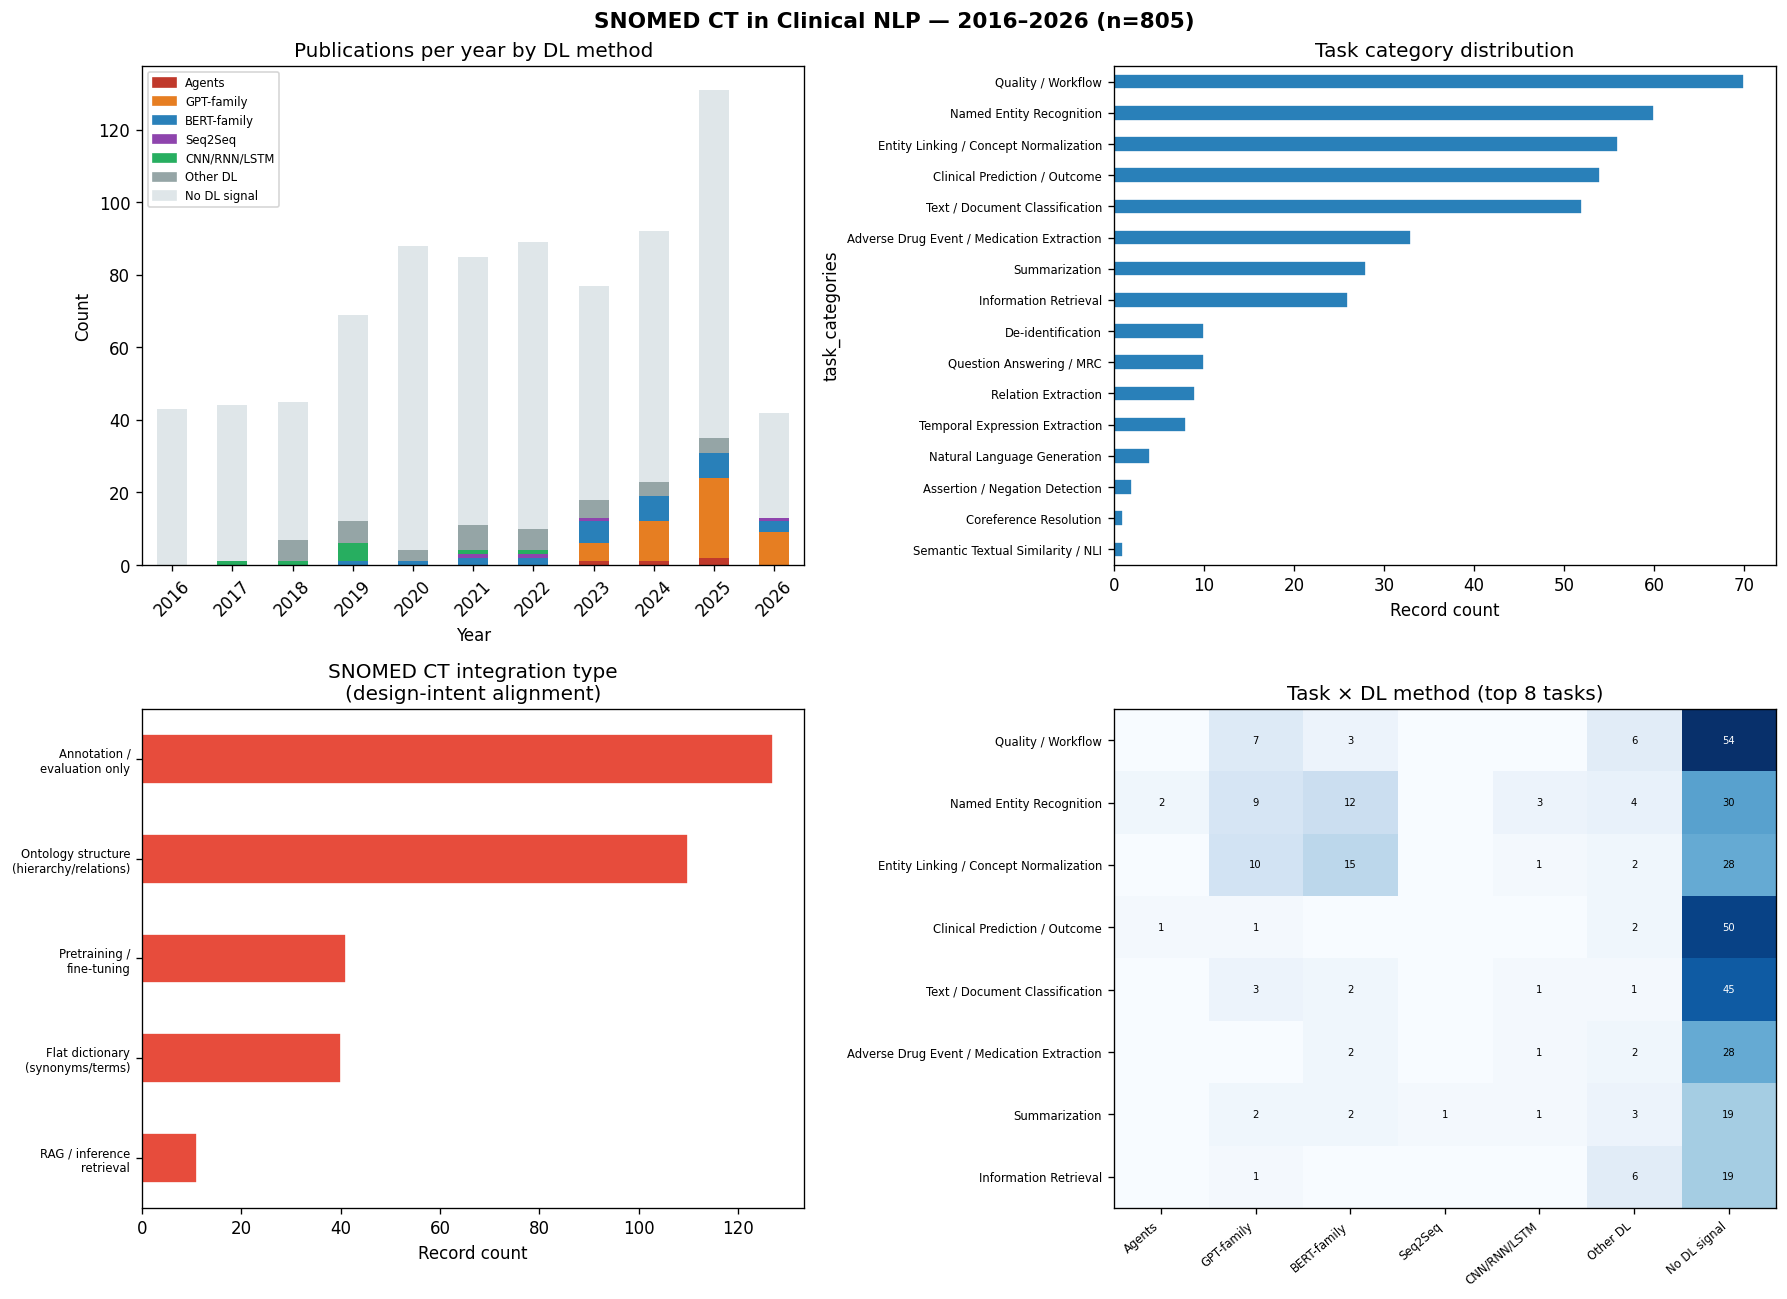

Saved results/fig_analysis.png

DL-only scope  :  134 records → results/scope_dl_only.csv
Agents scope   :    4 records → results/scope_agents.csv
Per-task CSVs  : results/by_task/  (16 files)

── Task × DL method (DL records only) ───
dl_method                                   agents  bert_family  gpt_family  lstm_rnn  other_dl  seq2seq
task                                                                                                    
Adverse Drug Event / Medication Extraction       0            2           0         1         2        0
Assertion / Negation Detection                   0            0           0         1         0        0
Clinical Prediction / Outcome                    1            0           1         0         2        0
De-identification                                0            0           0         0         1        0
Entity Linking / Concept Normalization           0           15          10         1         2        0
Information Retrieval        

In [ ]:
METHOD_ORDER  = ["agents", "gpt_family", "bert_family", "seq2seq", "lstm_rnn", "other_dl", "none"]
METHOD_LABELS = {"agents": "Agents", "gpt_family": "GPT-family", "bert_family": "BERT-family",
                 "seq2seq": "Seq2Seq", "lstm_rnn": "CNN/RNN/LSTM", "other_dl": "Other DL", "none": "No DL signal"}
METHOD_COLORS = {"agents": "#c0392b", "gpt_family": "#e67e22", "bert_family": "#2980b9",
                 "seq2seq": "#8e44ad", "lstm_rnn": "#27ae60", "other_dl": "#95a5a6", "none": "#dfe6e9"}

valid_years = (
    tagged.dropna(subset=["year"])
    .assign(year=lambda d: d["year"].astype(int))
    .query(f"{YEAR_START} <= year <= {YEAR_END}")
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("SNOMED CT in Clinical NLP — 2016–2026 (n=805)", fontsize=13, fontweight="bold")

# Fig 1: Papers per year stacked by DL method
present_methods = [m for m in METHOD_ORDER if m in tagged["dl_method"].values]
year_method = (
    valid_years.groupby(["year", "dl_method"]).size()
    .unstack(fill_value=0)
    .reindex(columns=present_methods, fill_value=0)
)
year_method.plot(kind="bar", stacked=True, ax=axes[0, 0],
                 color=[METHOD_COLORS[m] for m in year_method.columns], legend=False)
axes[0, 0].set_title("Publications per year by DL method")
axes[0, 0].set_xlabel("Year"); axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=45)
handles = [plt.Rectangle((0,0),1,1, color=METHOD_COLORS[m]) for m in year_method.columns]
axes[0, 0].legend(handles, [METHOD_LABELS[m] for m in year_method.columns],
                  fontsize=7, loc="upper left")

# Fig 2: Task category distribution
task_counts = (
    tagged["task_categories"].str.split("; ").explode()
    .replace("unclassified", None).dropna().value_counts().sort_values()
)
task_counts.plot(kind="barh", ax=axes[0, 1], color="#2980b9", edgecolor="white")
axes[0, 1].set_title("Task category distribution")
axes[0, 1].set_xlabel("Record count")
axes[0, 1].tick_params(axis="y", labelsize=7)

# Fig 3: SNOMED integration type (design-intent alignment)
use_labels = {"flat_dict": "Flat dictionary\n(synonyms/terms)",
              "hierarchy": "Ontology structure\n(hierarchy/relations)",
              "training":  "Pretraining /\nfine-tuning",
              "rag":       "RAG / inference\nretrieval",
              "evaluation":"Annotation /\nevaluation only"}
use_counts = (
    tagged["snomed_use"].str.split("; ").explode()
    .replace("unspecified", None).dropna().value_counts().sort_values()
)
use_counts.index = [use_labels.get(i, i) for i in use_counts.index]
use_counts.plot(kind="barh", ax=axes[1, 0], color="#e74c3c", edgecolor="white")
axes[1, 0].set_title("SNOMED CT integration type\n(design-intent alignment)")
axes[1, 0].set_xlabel("Record count")
axes[1, 0].tick_params(axis="y", labelsize=7)

# Fig 4: DL method × top 8 tasks heatmap
top_tasks = (
    tagged["task_categories"].str.split("; ").explode()
    .replace("unclassified", None).dropna().value_counts().head(8).index.tolist()
)
heatmap_data = []
for task in top_tasks:
    row_data = {}
    for method in present_methods:
        mask = (tagged["dl_method"] == method) & \
               tagged["task_categories"].str.contains(task, regex=False, na=False)
        row_data[METHOD_LABELS[method]] = mask.sum()
    heatmap_data.append(row_data)
hm = pd.DataFrame(heatmap_data, index=top_tasks)
im = axes[1, 1].imshow(hm.values, aspect="auto", cmap="Blues")
axes[1, 1].set_xticks(range(len(hm.columns))); axes[1, 1].set_xticklabels(hm.columns, rotation=40, ha="right", fontsize=7)
axes[1, 1].set_yticks(range(len(hm.index)));   axes[1, 1].set_yticklabels(hm.index, fontsize=7)
axes[1, 1].set_title("Task × DL method (top 8 tasks)")
for r in range(len(hm.index)):
    for c in range(len(hm.columns)):
        v = int(hm.values[r, c])
        if v > 0:
            axes[1, 1].text(c, r, str(v), ha="center", va="center", fontsize=6,
                            color="white" if v > hm.values.max()*0.6 else "black")

plt.tight_layout()
plt.savefig(CONFIG["output_dir"] / "fig_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/fig_analysis.png\n")

# Scoped filtered CSVs
dl_only    = tagged[tagged["has_dl"]].reset_index(drop=True)
agents_only= tagged[tagged["is_agent"]].reset_index(drop=True)
dl_only.to_csv(CONFIG["output_dir"] / "scope_dl_only.csv", index=False)
agents_only.to_csv(CONFIG["output_dir"] / "scope_agents.csv", index=False)

task_dir = CONFIG["output_dir"] / "by_task"
task_dir.mkdir(exist_ok=True)
for cat_name in TASK_TAGS:
    subset = tagged[tagged["task_categories"].str.contains(cat_name, regex=False, na=False)]
    if len(subset):
        fname = cat_name.lower().replace(" / ", "_").replace(" ", "_") + ".csv"
        subset.to_csv(task_dir / fname, index=False)

print(f"DL-only scope  : {len(dl_only):4d} records → results/scope_dl_only.csv")
print(f"Agents scope   : {len(agents_only):4d} records → results/scope_agents.csv")
print(f"Per-task CSVs  : results/by_task/  ({len(list(task_dir.iterdir()))} files)")

# Task × DL method breakdown table
print("\n── Task × DL method (DL records only) ───")
dl_task = (
    dl_only["task_categories"].str.split("; ").explode()
    .reset_index().merge(dl_only[["dl_method"]], left_on="index", right_index=True)
    .rename(columns={"task_categories": "task"})
    .query("task != 'unclassified'")
    .groupby(["task", "dl_method"]).size().unstack(fill_value=0)
)
dl_task.to_csv(CONFIG["output_dir"] / "task_by_dl_method.csv")
print(dl_task.to_string())

---
## 8. Clinical Concept Identification (CCI) Pipeline Scope

Narrows the corpus to papers covering the two-stage CCI pipeline: span detection (NER) and
SNOMED CT normalization / entity linking. These are the papers where SNOMED's design-intent
alignment argument is directly testable.

**Three-way task label** assigned by title-first, abstract-second screening:

| Label | Definition | Review priority |
|---|---|---|
| `linking_only` | Concept normalization / entity linking; SNOMED is the target ontology | High |
| `full_pipeline` | NER + normalization end-to-end; SNOMED enters at stage 2 | High |
| `ner_only` | Span detection; SNOMED appears in annotation or evaluation only | Standard |
| `manual_review` | Title and abstract both ambiguous — read methods section | High |

Papers with `full_pipeline` or `manual_review` labels are the most analytically valuable:
they reveal how SNOMED is used at the normalization stage of a real pipeline.

In [ ]:
# 8. CCI pipeline scope + triage

NER_TERMS  = [t.lower() for t in TASK_TAGS["Named Entity Recognition"]]
LINK_TERMS = [t.lower() for t in TASK_TAGS["Entity Linking / Concept Normalization"]]

def assign_cci_label(row) -> str:
    title    = (row.get("title",    "") or "").lower()
    abstract = (row.get("abstract", "") or "").lower()

    # Pass 1 — title
    ner_t  = any(t in title for t in NER_TERMS)
    link_t = any(t in title for t in LINK_TERMS)
    if ner_t and link_t:  return "full_pipeline"
    if link_t:            return "linking_only"
    if ner_t:             return "ner_only"

    # Pass 2 — abstract
    ner_a  = any(t in abstract for t in NER_TERMS)
    link_a = any(t in abstract for t in LINK_TERMS)
    if ner_a and link_a:  return "full_pipeline"
    if link_a:            return "linking_only"
    if ner_a:             return "ner_only"

    return "manual_review"

PRIORITY = {"linking_only": 1, "full_pipeline": 1, "manual_review": 1, "ner_only": 2}

cci_scope = (
    tagged[
        tagged["task_categories"].str.contains(
            "Named Entity Recognition|Entity Linking", regex=True, na=False
        ) & tagged["has_dl"]
    ]
    .copy()
    .drop_duplicates(subset=["title"])
)

cci_scope["cci_label"]       = cci_scope.apply(assign_cci_label, axis=1)
cci_scope["review_priority"] = cci_scope["cci_label"].map(PRIORITY)
cci_scope = cci_scope.sort_values(["review_priority", "year"], ascending=[True, False])

cci_scope.to_csv(CONFIG["output_dir"] / "scope_cci_pipeline.csv", index=False)

print(f"CCI pipeline scope: {len(cci_scope)} unique papers\n")
print(cci_scope["cci_label"].value_counts().to_string())
print(f"\nHigh-priority (linking_only + full_pipeline + manual_review): "
      f"{(cci_scope['review_priority'] == 1).sum()}")

CCI pipeline scope: 50 unique papers

cci_label
ner_only         23
linking_only     21
full_pipeline     6

High-priority (linking_only + full_pipeline + manual_review): 27
